# Is FTIR EC missing the char? — presentation figures for Ann

Figures built around the new working hypothesis from the meeting with Ann, Hossein and (earlier) Warren:
the Addis fAbs–EC anomaly may not be a HIPS problem at all — **FTIR EC may be under-reading char/charcoal
carbon** because the IMPROVE-based PLS calibration contains essentially no charcoal-type burning.

The story told by these figures:

1. **The anomaly, in context** — Addis has a beautiful fAbs–EC line (R² 0.76) with slope ≈ 4 and a large
   positive intercept (~28 Mm⁻¹ ≈ 7 µg/m³ of "missing" EC). Delhi shows the *same* signature.
2. **Two additive fixes the data cannot distinguish** — shift EC up by ~7 µg/m³ (FTIR misses mass) or shift
   fAbs down by ~28 Mm⁻¹ (HIPS reads high). Both preserve the slope and the R².
3. **Ann's seasonality test** — if the offset is missing *charcoal*, it should follow the charcoal seasons
   (Naveed's PMF: more charcoal influence in the rainy season). A constant-offset instrument artifact should not.
4. **Reconciling with history** — Schauer-era TOR EC in Addis (~13.7 µg/m³, mid-2010s) vs today's FTIR EC
   (~5) vs the corrected readings (~12): maybe EC never declined, FTIR just doesn't see a third of it.
5. **Is an Addis-like line anywhere in IMPROVE?** — per-site slope/intercept/R² for the whole IMPROVE
   network with the SPARTAN sites overlaid (also answers "is an R² this good even plausible?").

Sources: SPARTAN unified filter dataset (FTIR EC + HIPS fAbs, same-filter pairs) and the IMPROVE FED pull
(cached by `follow_up_mass_and_ratio_plots.ipynb`).


## 0. Setup

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "AGENTS.md").exists() and (cand / "research").exists():
            return cand
    raise RuntimeError("Could not locate repo root (AGENTS.md). CWD=%s" % Path.cwd())


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT / "research/ftir_hips_chem/scripts"))
try:
    from plotting import apply_default_style
    apply_default_style()
except Exception as e:
    print("plotting package unavailable (%s)" % e)

SPARTAN_PKL = REPO_ROOT / "research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl"
IMPROVE_CACHE = (REPO_ROOT / "research/improve_hips_offset/data_improve/Data/Improve/"
                 "improve_chemistry_clean_cache.pkl")

OUT = REPO_ROOT / "research/spartan/presentation_offset_story"
FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

SITE_COLORS = {"CHTS": "#8E44AD", "ETAD": "#E67E22", "INDH": "#16A085", "USPA": "#2C3E50"}
SITE_NAMES = {"CHTS": "Beijing", "ETAD": "Addis Ababa", "INDH": "Delhi", "USPA": "Pasadena/JPL"}
plt.rcParams.update({"axes.titlesize": 11.5, "axes.labelsize": 10.5})


def ols(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 3:
        return None
    slope, intercept = np.polyfit(x, y, 1)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    return {"n": len(x), "slope": slope, "intercept": intercept, "r2": r2}


print("Figures ->", FIG_DIR)

Figures -> /home/user/aethmodular/research/spartan/presentation_offset_story/figures


## 1. Same-filter fAbs + FTIR EC pairs

In [2]:
sp = pd.read_pickle(SPARTAN_PKL)
sp["SampleDate"] = pd.to_datetime(sp["SampleDate"], errors="coerce")
sp["base"] = sp["FilterId"].astype(str).str.replace(r"-\d+$", "", regex=True)


def par(name):
    d = sp.loc[sp["Parameter"].eq(name), ["Site", "base", "SampleDate", "Concentration"]]
    return d.rename(columns={"Concentration": name})


pairs = (par("HIPS_Fabs")
         .merge(par("EC_ftir"), on=["Site", "base", "SampleDate"], how="inner")
         .dropna(subset=["HIPS_Fabs", "EC_ftir"]))

site_fits = {s: ols(g["EC_ftir"], g["HIPS_Fabs"]) for s, g in pairs.groupby("Site")}
fit_tab = pd.DataFrame(site_fits).T
fit_tab["implied_missing_EC_ugm3"] = fit_tab["intercept"] / fit_tab["slope"]
fit_tab.round(3).to_csv(TAB_DIR / "spartan_site_fits.csv")
fit_tab.round(3)

,n,slope,intercept,r2,implied_missing_EC_ugm3
CHTS,163.0,5.590,6.212,0.543,1.111
ETAD,190.0,4.023,28.324,0.764,7.040
INDH,63.0,3.823,23.316,0.764,6.099
USPA,130.0,8.135,0.692,0.522,0.085


## Figure P1 — the anomaly, in context

Same axes for all four sites. Addis is not noisy or broken: it has the *tightest* relationship of any
site — just with a slope of ~4 instead of ~10 and an intercept of ~28 Mm⁻¹. And Delhi, the other
charcoal-heavy site, shows the same structure. Pasadena and Beijing look like the calibration expects
(intercept ≈ 0, slope closer to 10, more scatter).

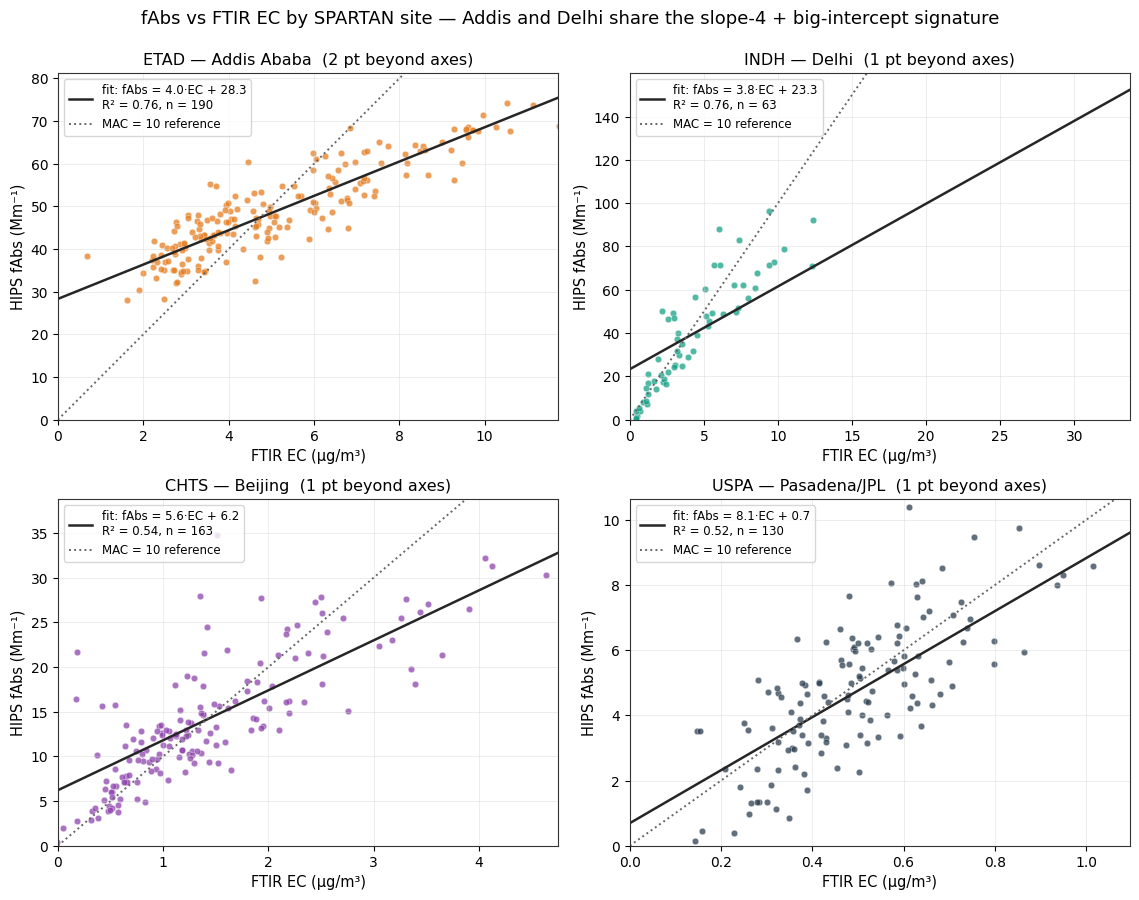

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 9), sharex=False, sharey=False)
order = ["ETAD", "INDH", "CHTS", "USPA"]
for ax, site in zip(axes.flat, order):
    g = pairs[pairs["Site"].eq(site)]
    f = site_fits[site]
    ax.scatter(g["EC_ftir"], g["HIPS_Fabs"], s=22, color=SITE_COLORS[site], alpha=0.75,
               edgecolor="white", linewidth=0.3)
    xmax = g["EC_ftir"].quantile(0.99) * 1.1
    ymax = g["HIPS_Fabs"].quantile(0.99) * 1.1
    n_out = int(((g["EC_ftir"] > xmax) | (g["HIPS_Fabs"] > ymax)).sum())
    xs = np.linspace(0, xmax, 50)
    ax.plot(xs, f["slope"] * xs + f["intercept"], color="0.15", lw=1.8,
            label=f"fit: fAbs = {f['slope']:.1f}·EC + {f['intercept']:.1f}\nR² = {f['r2']:.2f}, n = {f['n']}")
    ax.plot(xs, 10 * xs, color="0.4", ls=":", lw=1.4, label="MAC = 10 reference")
    title = f"{site} — {SITE_NAMES[site]}"
    if n_out:
        title += f"  ({n_out} pt beyond axes)"
    ax.set_title(title)
    ax.set_xlabel("FTIR EC (µg/m³)")
    ax.set_ylabel("HIPS fAbs (Mm⁻¹)")
    ax.legend(fontsize=8.5, loc="upper left")
    ax.set_xlim(0, xmax); ax.set_ylim(0, ymax)
fig.suptitle("fAbs vs FTIR EC by SPARTAN site — Addis and Delhi share the slope-4 + big-intercept signature",
             y=0.995, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "P1_anomaly_in_context.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure P2 — two additive fixes the data cannot tell apart

Using the fitted ETAD line (slope %s, intercept %s):
- **fix A (FTIR misses mass):** add intercept/slope ≈ 7.0 µg/m³ to every EC value — the line goes through
  zero, the slope stays 4, R² unchanged. Implies a MAC of ~4 m²/g.
- **fix B (HIPS reads high):** subtract ~28 Mm⁻¹ from every fAbs — same line through zero, same R².

Both are *purely additive*; regressions (OLS vs Deming) can't separate them, and multiplicative fixes
destroy the R². The discriminating evidence has to come from physics (the KBR charcoal spectra) or from
structure in time (Figure P3).

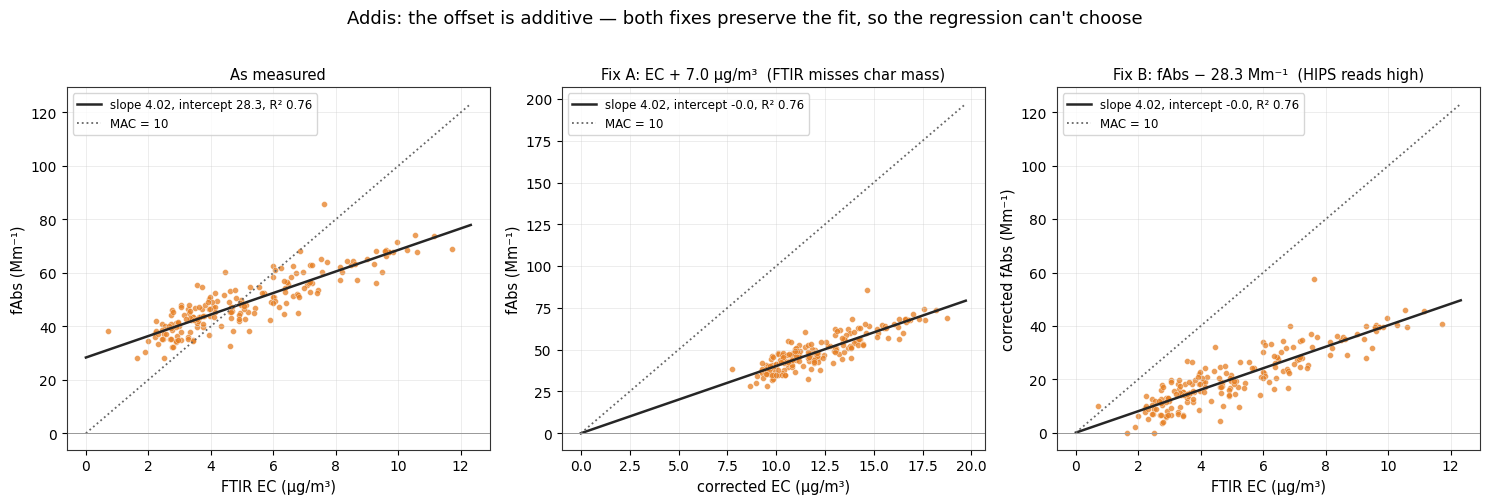

In [4]:
e = pairs[pairs["Site"].eq("ETAD")].copy()
f = site_fits["ETAD"]
dEC = f["intercept"] / f["slope"]          # ~7.0 ug/m3
dF = f["intercept"]                        # ~28.3 Mm-1

panels = [
    ("As measured", e["EC_ftir"], e["HIPS_Fabs"],
     "FTIR EC (µg/m³)", "fAbs (Mm⁻¹)"),
    (f"Fix A: EC + {dEC:.1f} µg/m³  (FTIR misses char mass)", e["EC_ftir"] + dEC, e["HIPS_Fabs"],
     "corrected EC (µg/m³)", "fAbs (Mm⁻¹)"),
    (f"Fix B: fAbs − {dF:.1f} Mm⁻¹  (HIPS reads high)", e["EC_ftir"], e["HIPS_Fabs"] - dF,
     "FTIR EC (µg/m³)", "corrected fAbs (Mm⁻¹)"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.9))
for ax, (title, x, y, xl, yl) in zip(axes, panels):
    st = ols(x, y)
    ax.scatter(x, y, s=18, color=SITE_COLORS["ETAD"], alpha=0.75, edgecolor="white", linewidth=0.3)
    xs = np.linspace(0, np.max(x) * 1.05, 50)
    ax.plot(xs, st["slope"] * xs + st["intercept"], color="0.15", lw=1.8,
            label=f"slope {st['slope']:.2f}, intercept {st['intercept']:.1f}, R² {st['r2']:.2f}")
    ax.plot(xs, 10 * xs, color="0.4", ls=":", lw=1.3, label="MAC = 10")
    ax.axhline(0, color="0.6", lw=0.7)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=8.5, loc="upper left")
fig.suptitle("Addis: the offset is additive — both fixes preserve the fit, so the regression can't choose",
             y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "P2_two_additive_fixes.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure P3 — Ann's test: is the "missing EC" constant, or does it follow the charcoal seasons?

If FTIR is missing *charcoal* carbon, the missing amount should track charcoal influence, which Naveed's
PMF shows is strongest in the rainy season (kiremt, Jun–Sep). A constant offset across seasons would point
instead to something instrument-like. Per filter we compute

`missing EC = fAbs / slope − EC_FTIR`   (slope from the all-data ETAD fit, i.e. assuming MAC ≈ 4)

and look at it by month, plus independent per-season regressions.

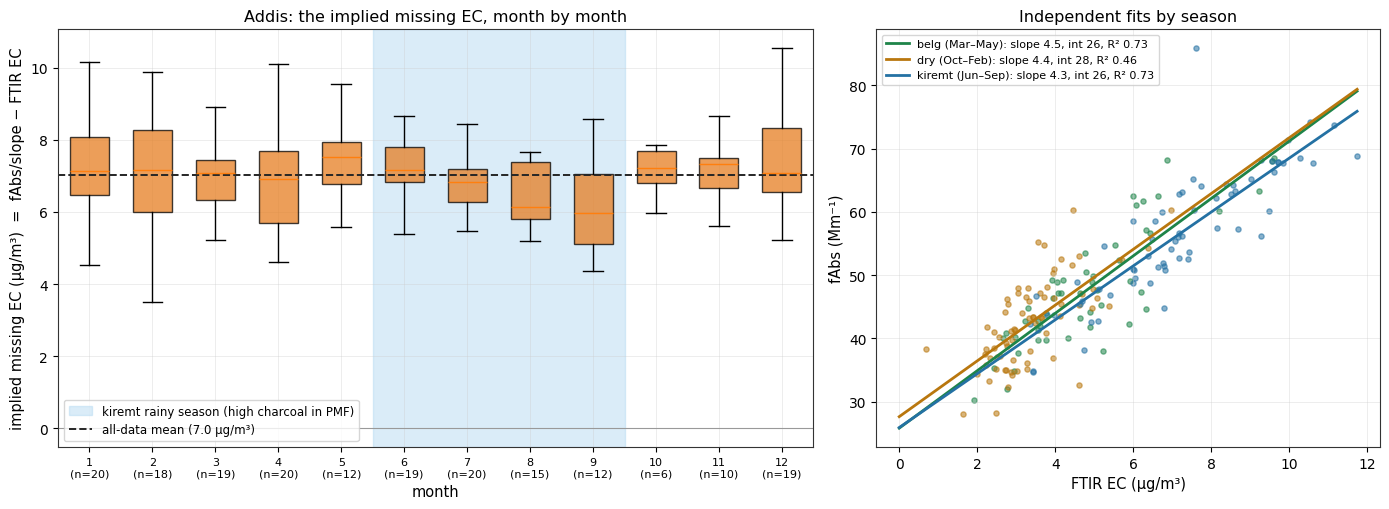

,season,n,slope,intercept,r2,missing_EC
0,belg (Mar–May),51,4.538,25.833,0.726,5.693
1,dry (Oct–Feb),73,4.409,27.645,0.457,6.271
2,kiremt (Jun–Sep),66,4.259,25.925,0.732,6.087


In [5]:
e["missing_EC"] = e["HIPS_Fabs"] / f["slope"] - e["EC_ftir"]
e["month"] = e["SampleDate"].dt.month
season_map = {12: "dry (Oct–Feb)", 1: "dry (Oct–Feb)", 2: "dry (Oct–Feb)", 10: "dry (Oct–Feb)",
              11: "dry (Oct–Feb)", 3: "belg (Mar–May)", 4: "belg (Mar–May)", 5: "belg (Mar–May)",
              6: "kiremt (Jun–Sep)", 7: "kiremt (Jun–Sep)", 8: "kiremt (Jun–Sep)", 9: "kiremt (Jun–Sep)"}
e["season"] = e["month"].map(season_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
months = range(1, 13)
data = [e.loc[e["month"].eq(m), "missing_EC"].dropna().values for m in months]
ax.axvspan(5.5, 9.5, color="#AED6F1", alpha=0.45, label="kiremt rainy season (high charcoal in PMF)")
bp = ax.boxplot(data, positions=list(months), showfliers=False, patch_artist=True, widths=0.62)
for patch in bp["boxes"]:
    patch.set_facecolor(SITE_COLORS["ETAD"]); patch.set_alpha(0.75)
ax.axhline(e["missing_EC"].mean(), color="0.15", ls="--", lw=1.4,
           label=f"all-data mean ({e['missing_EC'].mean():.1f} µg/m³)")
ax.axhline(0, color="0.6", lw=0.8)
counts = e.groupby("month").size()
ax.set_xticks(list(months))
ax.set_xticklabels([f"{m}\n(n={counts.get(m, 0)})" for m in months], fontsize=8)
ax.set_xlabel("month")
ax.set_ylabel("implied missing EC (µg/m³)  =  fAbs/slope − FTIR EC")
ax.set_title("Addis: the implied missing EC, month by month")
ax.legend(fontsize=8.5)

ax = axes[1]
rows = []
for season, g in e.groupby("season"):
    st = ols(g["EC_ftir"], g["HIPS_Fabs"])
    rows.append({"season": season, **st, "missing_EC": st["intercept"] / st["slope"]})
    xs = np.linspace(0, e["EC_ftir"].max(), 50)
    color = {"dry (Oct–Feb)": "#B9770E", "belg (Mar–May)": "#1E8449", "kiremt (Jun–Sep)": "#2471A3"}[season]
    ax.scatter(g["EC_ftir"], g["HIPS_Fabs"], s=14, color=color, alpha=0.55)
    ax.plot(xs, st["slope"] * xs + st["intercept"], color=color, lw=2,
            label=f"{season}: slope {st['slope']:.1f}, int {st['intercept']:.0f}, R² {st['r2']:.2f}")
ax.set_xlabel("FTIR EC (µg/m³)"); ax.set_ylabel("fAbs (Mm⁻¹)")
ax.set_title("Independent fits by season")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "P3_seasonal_offset_test.png", dpi=200, bbox_inches="tight")
plt.show()

season_fits = pd.DataFrame(rows)
season_fits.round(3).to_csv(TAB_DIR / "etad_seasonal_fits.csv", index=False)
season_fits.round(3)

## Figure P4 — reconciling Addis EC with history

The only independent Addis EC reference is the Schauer-group TOR measurement campaign from the mid-2010s
(~13.7 µg/m³ average — *number quoted from the paper in the meeting; confirm citation before presenting*).
Taken at face value next to today's FTIR EC (~5), it says Addis got dramatically cleaner. But both
offset-corrected readings of our own data land right next to the historical value — the simpler story may
be that EC never declined much, and FTIR under-reads it by ~7 µg/m³ worth of char.

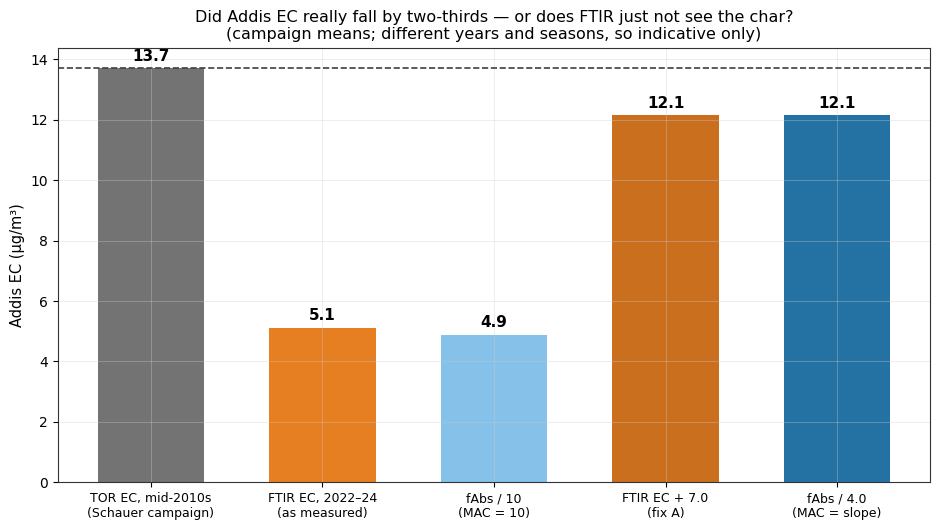

In [6]:
SCHAUER_TOR = 13.7   # ug/m3, Addis TOR EC mid-2010s, quoted in meeting — confirm citation
mean_ec = e["EC_ftir"].mean()
mean_fabs = e["HIPS_Fabs"].mean()

bars = [
    ("TOR EC, mid-2010s\n(Schauer campaign)", SCHAUER_TOR, "0.45"),
    ("FTIR EC, 2022–24\n(as measured)", mean_ec, SITE_COLORS["ETAD"]),
    ("fAbs / 10\n(MAC = 10)", mean_fabs / 10, "#85C1E9"),
    (f"FTIR EC + {dEC:.1f}\n(fix A)", mean_ec + dEC, "#CA6F1E"),
    (f"fAbs / {f['slope']:.1f}\n(MAC = slope)", mean_fabs / f["slope"], "#2471A3"),
]
fig, ax = plt.subplots(figsize=(9.5, 5.4))
xs = np.arange(len(bars))
for i, (label, val, color) in enumerate(bars):
    ax.bar(i, val, color=color, width=0.62)
    ax.text(i, val + 0.25, f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.axhline(SCHAUER_TOR, color="0.25", ls="--", lw=1.2)
ax.set_xticks(xs)
ax.set_xticklabels([b[0] for b in bars], fontsize=9)
ax.set_ylabel("Addis EC (µg/m³)")
ax.set_title("Did Addis EC really fall by two-thirds — or does FTIR just not see the char?\n"
             "(campaign means; different years and seasons, so indicative only)")
fig.tight_layout()
fig.savefig(FIG_DIR / "P4_history_reconciliation.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure P5 — is an Addis-like line anywhere in IMPROVE? (and is an R² this good plausible?)

Per-site OLS of fAbs on EC across the whole IMPROVE network (sites with ≥ 100 valid samples), placed in the
slope–intercept plane and the R² distribution, with the four SPARTAN sites overlaid. Two questions at once:
- does **any** US site combine a slope ≈ 4 with a ~28 Mm⁻¹ intercept? (if yes, pull its FTIR spectra)
- Addis's R² = 0.76 looked "too good" for an extreme site — how unusual is it really?

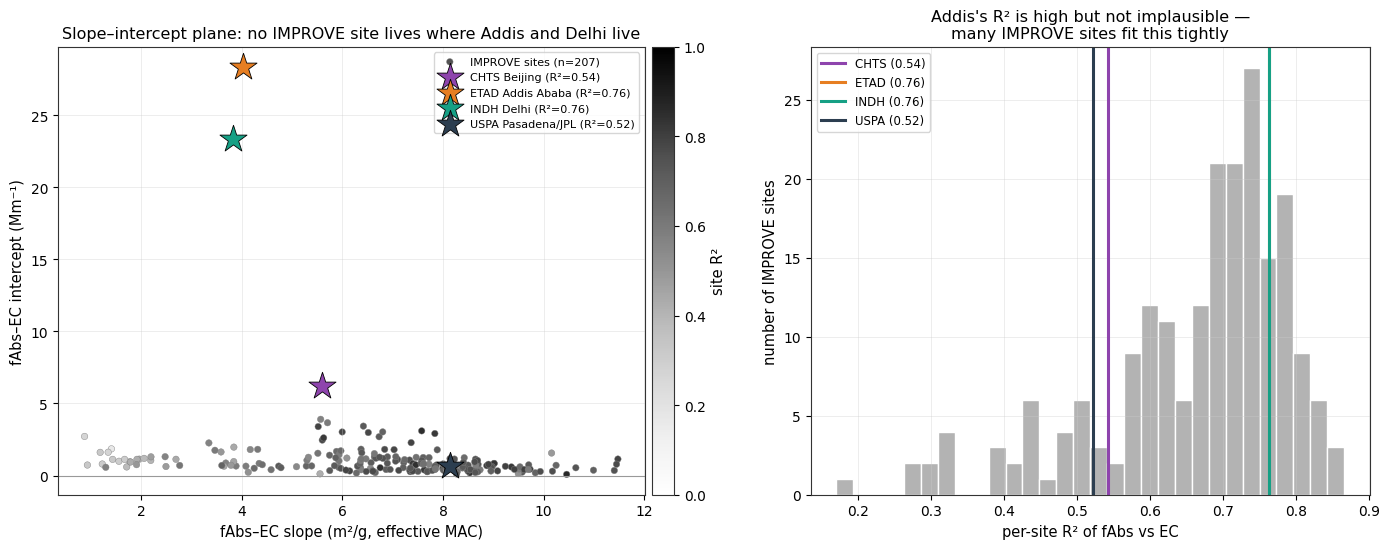

IMPROVE sites with intercept > 10 Mm⁻¹: Empty DataFrame
Columns: [SiteCode, slope, intercept, r2, n]
Index: []

Share of IMPROVE sites with R² >= ETAD's (0.76): 21.3%


In [7]:
imp = pd.read_pickle(IMPROVE_CACHE)
iv = imp[(imp["ECf_Val"] > 0) & (imp["fAbs_Val"] > 0)]

rows = []
for site, g in iv.groupby("SiteCode"):
    if len(g) < 100:
        continue
    st = ols(g["ECf_Val"], g["fAbs_Val"])
    rows.append({"SiteCode": site, **st})
imp_fits = pd.DataFrame(rows)
imp_fits.to_csv(TAB_DIR / "improve_site_fabs_ec_fits.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
sc = ax.scatter(imp_fits["slope"], imp_fits["intercept"], s=22, c=imp_fits["r2"],
                cmap="Greys", vmin=0, vmax=1, edgecolor="0.5", linewidth=0.3,
                label=f"IMPROVE sites (n={len(imp_fits)})")
cb = fig.colorbar(sc, ax=ax, pad=0.01); cb.set_label("site R²")
for site, st in site_fits.items():
    ax.scatter(st["slope"], st["intercept"], marker="*", s=420, color=SITE_COLORS[site],
               edgecolor="black", linewidth=0.6, zorder=5,
               label=f"{site} {SITE_NAMES[site]} (R²={st['r2']:.2f})")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("fAbs–EC slope (m²/g, effective MAC)")
ax.set_ylabel("fAbs–EC intercept (Mm⁻¹)")
ax.set_title("Slope–intercept plane: no IMPROVE site lives where Addis and Delhi live")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
ax.hist(imp_fits["r2"], bins=30, color="0.7", edgecolor="white")
for site, st in site_fits.items():
    ax.axvline(st["r2"], color=SITE_COLORS[site], lw=2.2, label=f"{site} ({st['r2']:.2f})")
ax.set_xlabel("per-site R² of fAbs vs EC")
ax.set_ylabel("number of IMPROVE sites")
ax.set_title("Addis's R² is high but not implausible —\nmany IMPROVE sites fit this tightly")
ax.legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "P5_improve_fit_plane.png", dpi=200, bbox_inches="tight")
plt.show()

print("IMPROVE sites with intercept > 10 Mm⁻¹:",
      imp_fits[imp_fits["intercept"] > 10][["SiteCode", "slope", "intercept", "r2", "n"]]
      .sort_values("intercept", ascending=False).to_string(index=False) or "none")
print(f"\nShare of IMPROVE sites with R² >= ETAD's ({site_fits['ETAD']['r2']:.2f}): "
      f"{(imp_fits['r2'] >= site_fits['ETAD']['r2']).mean():.1%}")

## Takeaways (to voice over the slides)

- **P1**: the anomaly is structural, not noise — and Delhi shares it (slope 3.8, intercept 23, same R²).
  Whatever it is, it lives where charcoal burning lives. Beijing and JPL behave like the calibration expects.
- **P2**: the data alone cannot distinguish "FTIR misses ~7 µg/m³" from "HIPS reads ~28 Mm⁻¹ high" —
  the regression algebra (see `research/addis_fabs_ec_deming/`) shows both are the same additive fix.
  That's exactly why the KBR charcoal-pellet spectra are the next experiment.
- **P3 — the surprise**: the implied missing EC is **flat across the year** (means 5.7–6.3 µg/m³ in all
  three seasons; per-season intercepts 26–28 Mm⁻¹ with slopes 4.3–4.5). Taking Ann's argument at face
  value, a missing-charcoal effect should swell in kiremt and shrink in the dry season — it doesn't.
  Honest caveats before over-reading it: charcoal *cooking* in Addis is year-round (the PMF seasonality is
  about relative source shares, not absolute charcoal mass), and fAbs/EC ranges shift between seasons. But
  as it stands this is evidence the offset behaves like a constant — which fits "the calibration mis-reads
  a base component present in every filter" or an instrument-side bias better than an episodic source story.
- **P4**: the corrected readings (~12 µg/m³ either way) reconcile today's data with the only historical TOR
  campaign (~13.7) — "Addis got 3× cleaner" may simply be "FTIR can't see a third of the EC".
- **P5**: nothing in 200+ IMPROVE sites reproduces the Addis/Delhi line (intercepts there live near 0–6
  Mm⁻¹) — consistent with the calibration never having seen this aerosol type. And the "suspiciously good"
  R² = 0.76 is unremarkable in the network distribution, so the tight Addis correlation is not itself a red flag.
